# 5101 EJERCICIOS CON MATPLOTLIB

El fichero titanic.csv contiene información sobre los pasajeros del Titanic. Crear un dataframe con Pandas y a partir de él generar los siguientes diagramas:
1. Diagrama de sectores con los fallecidos y supervivientes.
2. Histograma con las edades.
3. Diagrama de barras con el número de personas en cada clase.
4. Diagrama de barras con el número de personas fallecidas y supervivientes en cada clase.
5. Diagrama de barras con el número de personas fallecidas y supervivientes acumuladas en cada clase

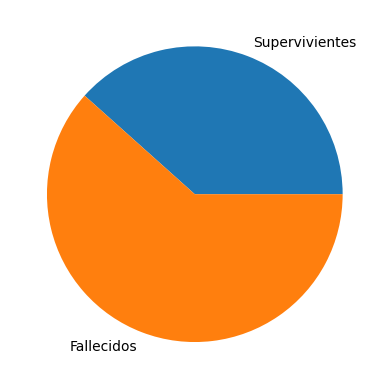

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('..\\datasets\\titanic.csv')

vivos = df.loc[df['Survived']==1].shape[0]
muertos = df.loc[df['Survived']==0].shape[0]

fig, ax = plt.subplots()
ax.pie([vivos,muertos], labels=['Supervivientes','Fallecidos'])
plt.show()

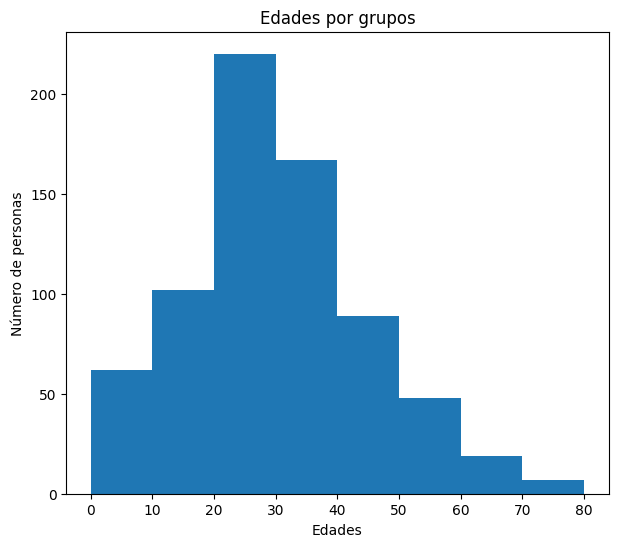

In [3]:
bins_edad = [0, 12, 18, 35, 60, 80]

s_edades= pd.Series(df['Age'])

plt.figure(figsize=[7,6])
plt.hist(s_edades,bins=[0, 10,20,30,40,50,60,70,80])
plt.title('Edades por grupos')
plt.xlabel('Edades')
plt.ylabel('Número de personas')
plt.show()

In [4]:
print(s_edades.describe())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

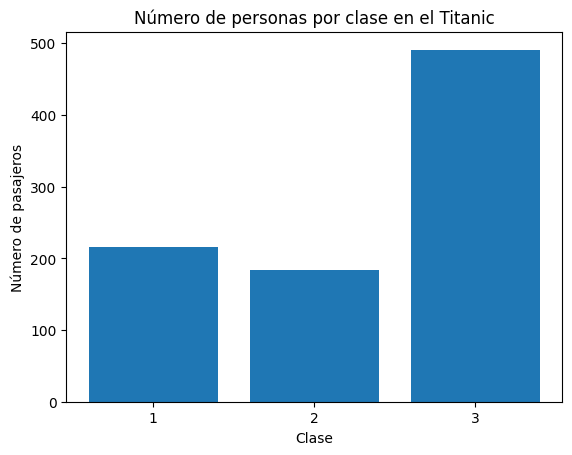

In [5]:
personas_clase = df['Pclass'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(personas_clase.index.astype(str), personas_clase.values)
ax.set_xlabel('Clase')
ax.set_ylabel('Número de pasajeros')
ax.set_title('Número de personas por clase en el Titanic')
plt.show

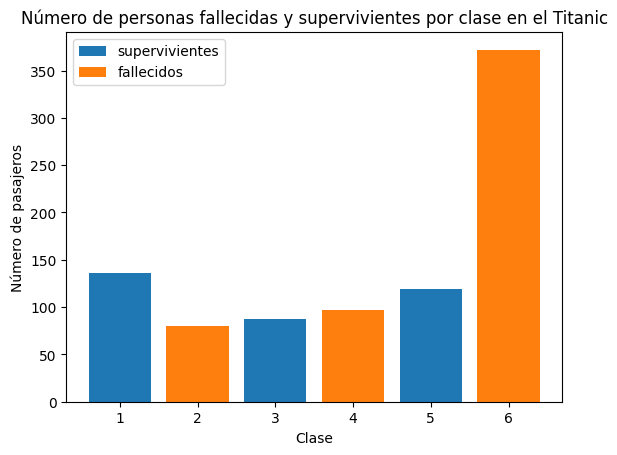

In [6]:
clas1_1 = df.loc[(df['Survived']==1) & (df['Pclass']==1)].shape[0]
clas1_0 = df.loc[(df['Survived']==0) & (df['Pclass']==1)].shape[0]
clas2_1 = df.loc[(df['Survived']==1) & (df['Pclass']==2)].shape[0]
clas2_0 = df.loc[(df['Survived']==0) & (df['Pclass']==2)].shape[0]
clas3_1 = df.loc[(df['Survived']==1) & (df['Pclass']==3)].shape[0]
clas3_0 = df.loc[(df['Survived']==0) & (df['Pclass']==3)].shape[0]

supervivientes= [clas1_1,clas2_1,clas3_1]
fallecidos = [clas1_0,clas2_0,clas3_0]
fig, ax = plt.subplots()
ax.bar([1,3,5],supervivientes, label='supervivientes')
ax.bar([2,4,6], fallecidos, label='fallecidos')
ax.set_xlabel('Clase')
ax.set_ylabel('Número de pasajeros')
ax.set_title('Número de personas fallecidas y supervivientes por clase en el Titanic')
ax.legend()
plt.show()

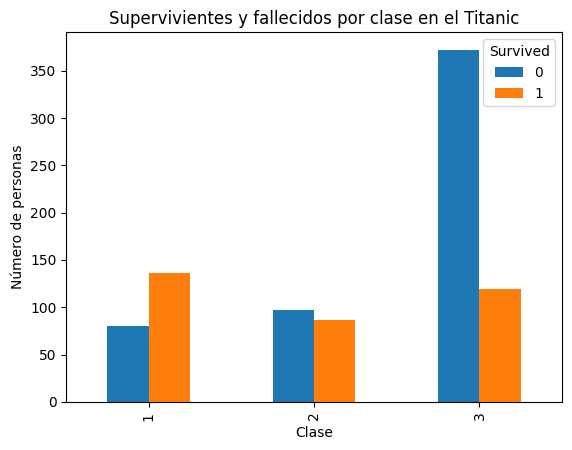

In [7]:
conteo = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0) 
#Cuenta cuántas filas hay por cada combinación de clase y supervivencia. .unstack Convierte el segundo nivel del índice (Survived) en columnas.
#| Pclass | 0 (fallecidos) | 1 (sobrevivientes) |
#| ------ | -------------- | ------------------ |
#| 1      | 80             | 136                |
#| 2      | 97             | 87                 |
#| 3      | 372            | 119                |

conteo.plot(kind='bar')
plt.xlabel("Clase")
plt.ylabel("Número de personas")
plt.title("Supervivientes y fallecidos por clase en el Titanic")
plt.show()


El fichero bancos.csv contiene las cotizaciones de los principales bancos de España con : 
- Empresa (nombre de la empresa), 
- Apertura (precio de la acción a la apertura de bolsa), 
- Máximo (precio máximo de la acción durante la jornada), 
- Mínimo (precio mínimo de la acción durante la jornada), 
- Cierre (precio de la acción al cierre de bolsa), 
- Volumen (volumen al cierre de bolsa).     

Construir una función reciba el fichero bancos.csv y cree un diagrama de líneas con las series temporales de las cotizaciones de cierre de cada banco

Escribir una función que reciba un dataframe de Pandas con los ingresos y gastos de una empresa por meses y devuelva un diagrama de líneas con dos líneas, una para los ingresos y otra para los gastos.    
El diagrama debe tener una leyenda identificando la línea de los ingresos y la de los gastos, un título con el nombre "Evolución de ingresos y gastos" y el eje y debe empezar en 0

Empresa     BBVA  Banco Sabadell  Banco Santander  Bankinter  Caixabank
Fecha                                                                  
2021-04-01  5.25         0.45530             3.42      5.852     2.6000
2021-04-05  5.33         0.46645             3.47      5.803     2.5875
2021-04-06  5.36         0.46560             3.48      5.802     2.5980
2021-04-07  5.41         0.46730             3.54      5.848     2.6170
2021-04-08  5.42         0.46070             3.51      5.876     2.5790
2021-04-09  5.30         0.46000             3.46      5.852     2.5870
2021-04-12  5.33         0.47000             3.47      5.832     2.6010
2021-04-13  5.29         0.46970             3.44      5.804     2.5590
2021-04-14  5.35         0.47190             3.48      5.830     2.5880
2021-04-15  5.23         0.45820             3.43      5.714     2.5350
2021-04-16  5.27         0.46530             3.46      5.800     2.5580
2021-04-19  5.42         0.47670             3.54      5.892    

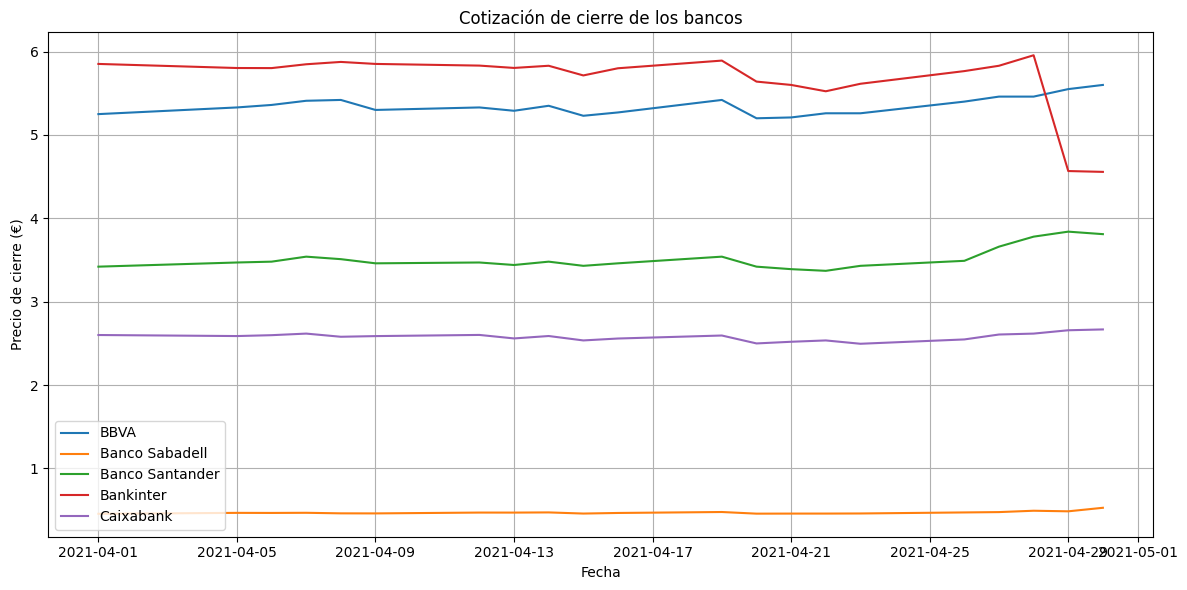

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df1 = pd.read_csv('..\\datasets\\bancos.csv')
def graficar_cotizaciones(df1):
    # 1. Leer CSV
    df = df1

    # 2. Convertir la columna Fecha a datetime
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    # 3. Reestructurar: filas → fechas, columnas → bancos, valores → cierre
    tabla = df.pivot_table( #.pivot_table = tablas dinámicas de excel, sirve para obtener una vista resumida de un DataFrame
        index="Fecha",
        columns="Empresa",
        values="Cierre"
    )

    mediana_sabadell = tabla['Banco Sabadell'].median()
    tabla['Banco Sabadell'] = tabla['Banco Sabadell'].fillna(mediana_sabadell)
    
    mediana_bankinter = tabla['Bankinter'].median()
    tabla['Bankinter'] = tabla['Bankinter'].fillna(mediana_bankinter)

    mediana_caixabank = tabla['Caixabank'].median()
    tabla['Caixabank'] = tabla['Caixabank'].fillna(mediana_caixabank)

    print(tabla)
    
    # 4. Crear la gráfica
    plt.figure(figsize=(12,6))
    for empresa in tabla.columns:
        plt.plot(tabla.index, tabla[empresa], label=empresa)

    # 5. Decoración del gráfico
    plt.title("Cotización de cierre de los bancos")
    plt.xlabel("Fecha")
    plt.ylabel("Precio de cierre (€)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # 6. Mostrar el gráfico
    plt.show()

graficar_cotizaciones(df1)

Escribir una función que reciba una serie de Pandas con el número de ventas de un producto por años y una cadena con el tipo de gráfico a generar (líneas, barras, sectores, areas) y devuelva un diagrama del tipo indicado con la evolución de las ventas por años y con el título "Evolución del número de ventas"

In [31]:

df = pd.DataFrame([[46,23,75,50,80],[12,23,34,56,67],[67,98,103,83,29],[198,280,366,100,201],[70,60,50,40,30]], index=['teclado', 'raton', 'usb', 'movil', 'pantalla'], columns=['2020', '2021', '2022', '2023', '2024'])

teclado = input('digame tipo de grafico')

def ventas_grafico(Serie, tipo):  

    serie = pd.DataFrame(Serie)
    #fig, ax = plt.subplots()

    if tipo == 'lineas':
        for producto in df.index:
            plt.plot(df.columns, df.loc[producto], marker="o", label=producto)
        plt.xlabel("Años")
        plt.ylabel("Número de ventas")
        plt.legend()
        plt.show

    elif tipo == 'barras':
        x = np.arange(len(df.columns)) #creamos conun array con un index en funcion del nº de columnas [0,1,2,3,4]
        ancho = 0.15

        for i, producto in enumerate(df.index):
            plt.bar(x + i * ancho, df.loc[producto], width=ancho, label=producto)
        
        plt.xticks(x + ancho * (len(df.index) - 1) / 2, df.columns)
        plt.xlabel("Años")
        plt.ylabel("Número de ventas")
        plt.legend()  
        
    elif tipo == 'sectores':
        sect=serie.values.sum()
        sect.head()
        #plt.pie(sect)
        #plt.show
    elif tipo == 'areas':
        plt.fill_between(serie)
        plt.show
    else:
        print('no ha elegido correctamente')
        
ventas_grafico(df, teclado)

AttributeError: 'numpy.int64' object has no attribute 'head'

Escribir una función que reciba una serie de Pandas con el número de ventas de un producto durante los meses de un trimestre y un título y cree un diagrama de sectores con las ventas en formato png con el título dado. El diagrama debe guardarse en un fichero con formato png y el título dado.

Escribir una función que reciba una serie de Pandas con las notas de los alumnos de un curso y devuelva un diagrama de cajas con las notas. El diagrama debe tenerel título "Distribución de notas".

Escribir una función que reciba un diccionario con las notas de las asignaturas de un curso y una cadena con el nombre de un color y devuelva un diagrama de barras de las notas en el color dado.

Escribir un programa que pregunte al usuario por las ventas de un rango de años y muestre por pantalla un diagrama de líneas con la evolución de las ventas.